# <font size = 5>Setting up</font>

In [4]:
# imports and suppress warnings
import numpy as np
import skimage
import mahotas
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import sys
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter
import pandas as pd
import scipy.constants
import pickle
from tkinter import filedialog # for prompting user to set analysis folder
import glob
from pathlib import PureWindowsPath, PurePosixPath
from lmfit import Model, Parameters
from lmfit.models import LinearModel
from PIL import Image
from scipy.special import jn, jn_zeros
from scipy.stats import halfnorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from numpy.fft import fft2, fftshift, ifftshift, ifft2, fft, fftfreq
import scipy.ndimage as ndimage
from numpy import ma

# suppress warnings: do at your own risk!
import warnings
warnings.filterwarnings("ignore")

In [5]:
# physics constants
ABSORPTION_LIMIT = 5.0
SPECIAL_CHARACTERS = "!@#$%^&*()-+?_=,<>/"

# physics constants
hbar = 1.05457182*10**(-34) # Js
c = 299792458 # m/s
h_planck = hbar*2*np.pi  # Js
me = 9.1093837015e-31    # electron mass
mn = 1.67493e-27         # neutron mass
eC = 1.60218e-19         # electric charge
muB = eC*hbar/(2*me)     # Bohr magneton
muB_cm1_G = muB / (100*c*h_planck*1e4) # Bohr magneton in units of cm-1 per Gauss
a0 = 5.2917720859e-11    # Bohr radius
muN = scipy.constants.physical_constants['nuclear magneton'][0]
eps0 = scipy.constants.epsilon_0
gS = 2.0023193043622
DebyeSI = 3.33564e-30
kB = 1.380649e-23

# Lithium constants
mLi6 = 9.9883414*10**(-27) # kg
Li6D2Gamma = 5.8724e6 # Hz Note that this is NOT angular freq
Li6D2lambda0 = 670.977338*10**(-9) # meters
Li6D2sigma0 = 3*(Li6D2lambda0)**2/(2*np.pi)
Li6Ahf_s12 = 152.1368407e6  # This is NOT angular freq
Li6Bhf_s12 = 0
Li6Ahf_p12 = 17.386e6 # Hz
Li6Bhf_p12 = 0
Li6Ahf_p32 = -1.155e6 # Hz
Li6Bhf_p32 = -0.10e6 # Hz
Li6I = 1
Li6gI = -0.0004476540

# Sodium-23 constants
mNa23 = 0.38175403519e-25 # kg
Na23D2Gamma = 9.794646e6 # Hz
Na23D2lambda0 = 589.158326415e-9 # meters
Na23D2sigma0 = 3*(Na23D2lambda0)**2/(2*np.pi)
Na23Ahf_s12 = 885.8130644050e6 # Hz
Na23Bhf_s12 = 0e6 # Hz
Na23Ahf_p12 = 94.4413e6 # Hz
Na23Bhf_p12 = 0e6 # Hz
Na23Ahf_p32 = 18.53415e6 # Hz
Na23Bhf_p32 = 2.72430e6 # Hz
Na23I = 3/2
Na23gI = -0.0008046108080

# Potassium-40 constants
mK40 = 39.9639984821*1.6605402e-27 # kg 
K40D2Gamma = 6.03511 # MHz
K40D2lambda0 = 766.700674872173e-9 # meters
K40D2sigma0 = 3*(K40D2lambda0)**2/(2*np.pi)
K40Ahf_s12 = -285.730824e6 # Hz
K40Bhf_s12 = 0
K40Ahf_p12 = -34.52325e6 # Hz
K40Bhf_p12 = 0
K40Ahf_p32 = -7.58510e6 # Hz
K40Bhf_p32 = -3.44590e6 # Hz
K40I = 4
K40gI = 0.00017649034

# NaK constants:
mK41 = 6.80187059497004e-26 # kg
mK40 = 6.63617749148248e-26 # kg
mK39 = 6.47007514485677e-26 # kg
u = 1.660538782e-27  # kg
Eh = 4.35974394e-18 
RKRcst = hbar/np.sqrt(2*u) * (10**10) * np.sqrt(1/(100 * c * hbar * 2*np.pi)) 
muNa39K = (mNa23 * mK39)/(mNa23 + mK39) * 1/u # atomic units
muNa40K = (mNa23 * mK40)/(mNa23 + mK40) * 1/u # atomic units 
muNa41K = (mNa23 * mK41)/(mNa23 + mK41) * 1/u # atomic units

In [6]:
# fancy plot
import matplotlib.pyplot as plt
import numpy as np
def fancy_plot(x, y, fmt='', ax = None, **kwargs):
    """Wraps around matplotlib.pyplot (aliased to plt) with last-point highlighting and statistics
    Plots x and y as in plt.plot, but a) averages together y-values with the same x-value and calculates and plots
    an error bar, and b) plots the final (x,y) point in a different color than the previous ones.
    Args:
        x: The x-data to be plotted. Assumed to be an iterable with contents of
            numeric type, including possibly np.nan
        y: The y-data to be plotted. Same assumptions on type.
        fmt: The format string. In contrast to ax.plot, it is a kwarg.
        ax: The axes object on which to plot. If None, plt.gca() is called.
        kwargs: Any kwarg that can be passed to ax.errorbar.
    Returns:
        ErrorbarContainer, as detailed in the docs for plt.errorbar
    Raises:
        ValueError if x and y are not of the same length
    """
    if(ax == None):
        ax = plt.gca()
    if(len(x) != len(y)):
        raise ValueError(
            "The input x and y arrays must be of the same length.")
    # Filter out the NaNs in either x or y while preserving order
    zipped_list = list(zip(x, y))
    nan_filter = filter(lambda v: (
        (not np.isnan(v[0])) and (not np.isnan(v[1]))), zipped_list)
    nan_stripped_list = list(nan_filter)
    # Sort the NaN-stripped list to make getting statistics faster for large data
    sorted_list = sorted(nan_stripped_list, key=(lambda v: v[0]))
    # Reconstitute to x- and y- lists
    if(len(sorted_list) > 0):
        x_sorted, y_sorted = zip(*sorted_list)
        sorted_x_list = list(x_sorted)
        sorted_y_list = list(y_sorted)
    else:
        sorted_x_list = []
        sorted_y_list = []
    # Perform statistics and condense repeated measurements
    index = 0
    final_x_list = []
    final_y_list = []
    final_error_list = []
    while(index < len(sorted_x_list)):
        current_x_value = sorted_x_list[index]
        final_x_list.append(current_x_value)
        y_list_for_current_x = []
        while(index < len(sorted_x_list) and sorted_x_list[index] == current_x_value):
            y_list_for_current_x.append(sorted_y_list[index])
            index += 1
        y_array_for_current_x = np.array(y_list_for_current_x)
        y_mean = sum(y_array_for_current_x) / float(len(y_array_for_current_x))
        final_y_list.append(y_mean)
        # Calculate the standard error of mean if possible
        if(len(y_list_for_current_x) == 1):
            final_error_list.append(np.nan)
        else:
            variance_estimate = sum(np.square(
                y_mean - y_array_for_current_x)) / float(len(y_array_for_current_x) - 1)
            standard_error_of_mean = np.sqrt(
                variance_estimate / len(y_array_for_current_x))
            final_error_list.append(standard_error_of_mean)
    # Convert all lists to np arrays
    final_x_values = np.array(final_x_list)
    final_y_values = np.array(final_y_list)
    final_error_values = np.array(final_error_list)
    # Plot and return the errorbar graph with the input kwargs
    return ax, ax.errorbar(final_x_values, final_y_values, final_error_values, fmt=fmt, **kwargs)

# <font size = 5>Microscope objective characterization: magnification</font>

Magnification: 
51.74361658232628


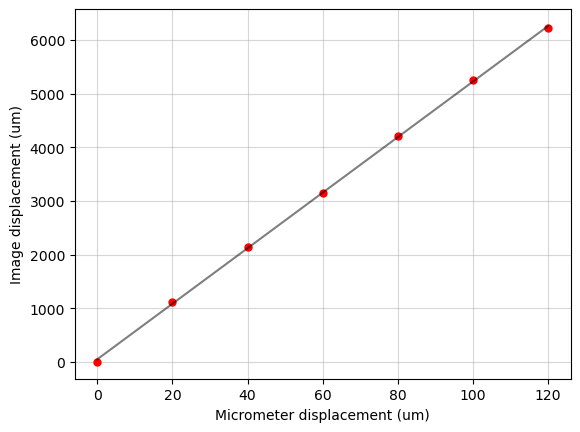

In [38]:
# magnification measurement

micrometer_screw_position = np.array([5.86, 5.88, 5.90, 5.92, 5.94, 5.96, 5.98]) # mm
x_loc = np.array([366, 271, 190, 115, 30, -42, -122]) # um
y_loc = np.array([2232, 1114, 100, -906, -1959, -2995, -3972]) # um

micrometer_screw_displacement = 1000 * (micrometer_screw_position - micrometer_screw_position[0]) # um
x_dis = x_loc - x_loc[0]
y_dis = y_loc - y_loc[0]
total_dis = np.sqrt(x_dis**2 + y_dis**2)

# fit line to model:
model = LinearModel()
params = model.make_params()
out = model.fit(total_dis, params, x = micrometer_screw_displacement)

print('Magnification: ')
print(out.params['slope'].value)

plt.plot(micrometer_screw_displacement, total_dis, '.', color = 'red', markersize = 10)
plt.xlabel('Micrometer displacement (um)')
plt.ylabel('Image displacement (um)')
plt.plot(micrometer_screw_displacement, out.best_fit, '-', label='best fit', color = 'black', alpha = 0.5)
plt.grid(alpha=0.5)
plt.show()


# <font size = 5>Microscope objective characterization: PSF</font>

In [58]:
# helper functions
def profile_gaussian_with_offset(x, amplitude, offset, Sx, Sy, x_center, y_center, theta):
    xx, yy = x
    x_prime =  np.cos(theta) * (xx-x_center) + np.sin(theta)*(yy-y_center)
    y_prime = -np.sin(theta) * (xx-x_center) + np.cos(theta)*(yy-y_center)
    profile_gaussian =  amplitude*np.exp(-x_prime**2/(2*Sx**2))*np.exp(-y_prime**2/(2*Sy**2)) + offset
    return profile_gaussian.ravel()

def find_center(data, show_fit = True):
    data = np.nan_to_num(data, nan = np.inf)
    y_size = np.shape(data)[0]
    x_size = np.shape(data)[1]
    x = np.linspace(0, x_size - 1, x_size)
    y = np.linspace(0, y_size - 1, y_size)
    X,Y = np.meshgrid(x,y)
    # generate initial guess
    amplitude_guess = np.max(data)
    offset_guess = 0
    Sx_guess = 5
    Sy_guess = 5
    x_center_guess = x_size//2
    y_center_guess = y_size//2
    theta_guess = 0
    # generate fit model:
    model = Model(profile_gaussian_with_offset)
    params = model.make_params(amplitude=amplitude_guess,
                               offset=offset_guess,
                               Sx=Sx_guess,
                               Sy = Sy_guess,
                               x_center = x_center_guess,
                               y_center = y_center_guess,
                               theta = theta_guess)
    lmfit_result = model.fit(data.ravel(), params, x= np.array((X, Y)), weights = None)
    report = lmfit_result.fit_report()
    # print(report)
    popt = lmfit_result.params
    # compute residuals
    data_fitted = profile_gaussian_with_offset((X,Y),
                                               amplitude = popt['amplitude'].value,
                                               offset = popt['offset'].value,
                                               Sx = popt['Sx'].value,
                                               Sy = popt['Sy'].value,
                                               x_center = popt['x_center'].value,
                                               y_center = popt['y_center'].value,
                                               theta = popt['theta'].value)
    data_fitted = data_fitted.reshape(y_size,x_size)
    residuals = data - data_fitted
    if show_fit:
        fig, ax = plt.subplots(1,4, figsize=(10,3))
        ax[0].contour(X, Y, data_fitted, 3, colors = 'white', linewidth = 0.1, alpha = 0.75)
        ax[0].pcolor(X, Y, data, cmap = 'plasma')
        ax[0].set_title(f'Sx = {popt["Sx"].value:.1f} px\n Sy = {popt["Sy"].value:.1f} px', fontsize = 12)
        ax[1].hist(residuals.ravel(), bins='auto', edgecolor='black', linewidth=0.1)
        ax[1].set_title(f'Histogram of residuals', fontsize = 12)
        ax[2].plot(x, data_fitted[y_size//2,:])
        ax[2].plot(x, data[y_size//2,:])
        ax[2].set_title('Cut along X at Y-center')
        ax[3].plot(y, data_fitted[:,x_size//2])
        ax[3].plot(y, data[:,x_size//2])
        ax[3].set_title('Cut along Y at X-center')
        plt.tight_layout()
        plt.show()
    return popt["x_center"].value, popt["y_center"].value

def radial_profile(data, center,  camera_magnification, imaging_magnification):
    y,x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    return r.ravel() * camera_magnification * 1000 / imaging_magnification, data.ravel()

def radial_profile_with_binning(data, center, bins, camera_magnification, imaging_magnification):
    y,x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    # now sort and bin
    s = np.argsort(r.ravel())
    sorted_r = r.ravel()[s] * camera_magnification * 1000 / imaging_magnification
    sorted_data = data.ravel()[s] # sorted by r
    r_binned_data, edges, _ = scipy.stats.binned_statistic(sorted_r, sorted_data, 'mean', bins=bins)
    r_binned = edges[:-1]
    return r_binned, r_binned_data/max(r_binned_data)

def ideal_psf(r, NA = 0.7, lam = 589):
    R = 0.61 * lam / NA # radius of first zero, lam in nm
    Rz = 1.2196698912665045
    u = np.pi * r / (R/Rz) # r in nm
    return (2 * jn(1, u) / u)**2

In [203]:
# single-image analysis
image_filename = 'FLIR_1.tiff'
image_file = '/Users/huanbui/Desktop/microscope_testing/20250211/FLIR_K/' + image_filename
# dark_folder = '/Users/huanbui/Desktop/microscope_testing/20250130'
dark_file = '/Users/huanbui/Desktop/microscope_testing/20250211/FLIR_K/FLIR_DARK.tiff'
camera_magnification = 1.85 # 6.45 # um per pixel
imaging_magnification = 49.7 # 51.7 # 51.7
# crop to get a smaller image to work faster
roi_size = 150
bins = roi_size
# dark = None
# for dark_file in os.listdir(dark_folder):
#     dark = np.array(Image.open(dark_folder + '/' + dark_file), dtype = 'int64')
# dark = dark / len(os.listdir(dark_folder))
dark = np.array(Image.open(dark_file), dtype = 'int64')
im = np.array(Image.open(image_file), dtype = 'int64')
im = im - dark
x_center_guess, y_center_guess = np.unravel_index(im.argmax(), im.shape)
design_NA = 0.55
lam = 767

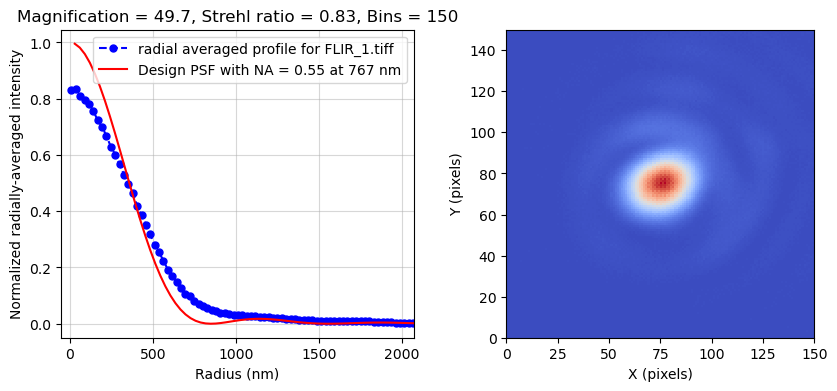

In [207]:
# run analysis
cropped = im[x_center_guess - int(roi_size/2):x_center_guess + int(roi_size/2), 
                y_center_guess - int(roi_size/2):y_center_guess + int(roi_size/2)]
# find center
x_center, y_center = find_center(cropped, show_fit=False)

# do radial average around centers
r_binned, r_binned_data = radial_profile_with_binning(cropped, 
                                                      [x_center, y_center], 
                                                      bins = bins, 
                                                      camera_magnification = camera_magnification, 
                                                      imaging_magnification = imaging_magnification)
fig, ax = plt.subplots(nrows = 1, ncols=2, figsize = (10,4))
r_psf = np.linspace(0,3000,100)
psf = ideal_psf(r_psf, NA = design_NA, lam = lam)
r_binned_data = np.nansum(ideal_psf(r_binned, NA = design_NA, lam = lam)) * r_binned_data/np.nansum(r_binned_data)

ax[0].plot(r_binned, r_binned_data, '.--', color = 'blue', markersize = 10, label = 'radial averaged profile for ' + image_filename)
ax[0].plot(r_psf, psf, color = 'red', label = f'Design PSF with NA = {design_NA} at {lam} nm')
ax[0].set_xlabel('Radius (nm)')
ax[0].set_ylabel('Normalized radially-averaged intensity')
ax[0].set_xlim([-50,2070])
ax[0].legend()
ax[0].grid(alpha = 0.5)
ax[0].set_title(f'Magnification = {imaging_magnification}, Strehl ratio = {r_binned_data[0]:.2f}, Bins = {bins}')

ax[1].pcolor(cropped, cmap = 'coolwarm')
ax[1].set_xlabel('X (pixels)')
ax[1].set_ylabel('Y (pixels)')
ax[1].axis('square')
plt.show()

In [4737]:
# multi-image analysis setup
image_folder = '/Users/huanbui/Desktop/microscope_testing/20250131/FOV_1/images'
dark_folder = '/Users/huanbui/Desktop/microscope_testing/20250131/FOV_1/dark_images'
camera_magnification = 6.45 # um per pixel
imaging_magnification = 49
roi_size = 25
bins = roi_size
design_NA = 0.60
# generate ideal PSF
r_psf = np.linspace(0,3000,100)
psf = ideal_psf(r_psf, NA = design_NA, lam = 589)
FOV_start, FOV_end = 24, 26

In [4738]:
# run multi-image analysis
dark = None
for dark_file in os.listdir(dark_folder):
    dark = np.array(Image.open(dark_folder + '/' + dark_file), dtype = 'int64')
dark = dark / len(os.listdir(dark_folder)) # get average dark shot
strehl_ratios = np.array([])
# create img file list in ascending numerical order
img_files = os.listdir(image_folder)
img_files.sort(key=lambda f: int(''.join(filter(str.isdigit,f)))) 
r_FOV = np.array([])
data_FOV = np.array([])
for i in range(len(img_files)):
    # print(img_file)
    im = np.array(Image.open(image_folder + '/' + img_files[i]), dtype = 'int64')
    im = im - dark
    x_center_guess, y_center_guess = np.unravel_index(im.argmax(), im.shape)
    cropped = im[x_center_guess - int(roi_size/2):x_center_guess + int(roi_size/2), 
                 y_center_guess - int(roi_size/2):y_center_guess + int(roi_size/2)]
    x_center, y_center = find_center(cropped, show_fit=False)
    r_binned, r_binned_data = radial_profile_with_binning(cropped, [x_center, y_center], bins, camera_magnification, imaging_magnification)
    # normalize to ideal PSF:
    r_binned_data = np.nansum(ideal_psf(r_binned, NA = design_NA, lam = 589)) * r_binned_data/np.nansum(r_binned_data)
    if FOV_start <= i <= FOV_end: 
        r, data = radial_profile(cropped, [x_center, y_center],  camera_magnification, imaging_magnification)
        r_FOV = np.append(r_FOV, r)
        data_FOV = np.append(data_FOV, data)        
    # compute Strehl ratio and add to list
    strehl_ratios = np.append(strehl_ratios, r_binned_data[0])

# get data from FOV:
s = np.argsort(r_FOV)
sorted_r_FOV = r_FOV[s]
sorted_data_FOV = data_FOV[s] # sorted by r
r_binned_data_FOV, edges, _ = scipy.stats.binned_statistic(sorted_r_FOV, sorted_data_FOV, 'mean', bins=np.sqrt(len(r_FOV)))
r_binned_FOV = edges[:-1]
r_binned_data_FOV = np.nansum(ideal_psf(r_binned_FOV, NA = design_NA, lam = 589)) * r_binned_data_FOV/np.nansum(r_binned_data_FOV)


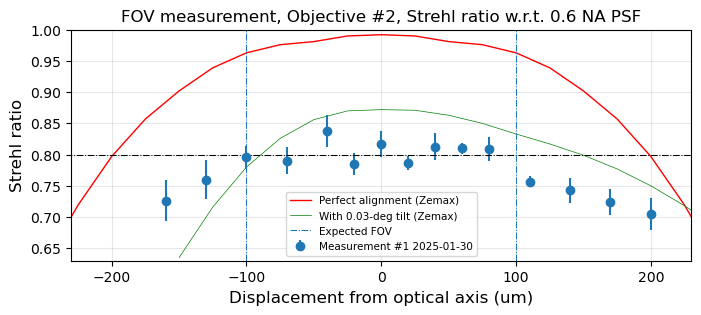

In [4739]:
# plotting FOV measurement:
design_FOV_displacement = np.array([0,25,-25,50,-50,75,-75,100,-100,125,-125,150,-150,175,-175,200,-200,225,-225,250,-250])
design_FOV_Strehl  = np.array([0.992,0.990,0.990,0.981,0.981,0.976,0.976,0.963,0.963,0.939,0.939,0.902,0.902,0.857,0.857,0.797,0.797,0.719,0.719,0.626, 0.626])
design_ind = np.argsort(design_FOV_displacement)

tilted_FOV_displacement = np.array([0,25,-25,50,-50,75,-75,100,-100,125,-125,150,-150,175,-175,200,-200,225,-225,250,-250]) + 100
tilted_FOV_Strehl = np.array([0.833,0.817,0.850,0.799,0.863,0.777,0.871,0.750,0.872,0.718,0.870,0.683,0.856,0.639,0.826,0.585,0.780,0.523,0.716,0.457,0.635])
tilted_ind = np.argsort(tilted_FOV_displacement)

# FOV 1 2025-01-29 bins = 20
FOV_1_displacement = np.array([0,30,60,90,120,-30,-60,-90,-120])
FOV_1_Strehl = np.array([0.82, 0.84, 0.78,0.79,0.68,0.81,0.84,0.79,0.68])
FOV_1_ind = np.argsort(FOV_1_displacement)

# FOV 2 2025-01-29 bins = 20
FOV_2_displacement = np.array([0,30,60,90,120,-30,-60,-90,-120,-150])
FOV_2_Strehl = np.array([0.84,0.78,0.78,0.81,0.72,0.85,0.80,0.83,0.72,0.70])
FOV_2_ind = np.argsort(FOV_2_displacement)

# FOV 1 2025-01-30
dis = np.array([220,220,220,250,250,250,280,280,280,310,310,310,340,340,340,
                370,370,370,400,400,400,220,220,220,190,190,190,160,160,160,
                130,130,130,100,100,100,70,70,70,40,40,40,
                10,10,10,-20,-20,-20,220,220,220]) - 190

# # FOV 1 2025-01-29
dis = np.array([260,260,260,280,280,280,300,300,300,220,220,220,240,240,240,200,200,200,170,170,170,
                140,140,140,110,110,110,80,80,80,320,320,320,350,350,350,380,380,380,410,410,410,440,440,440]) - 240

# plotting
plt.figure(figsize=(8, 3))
plt.plot(design_FOV_displacement[design_ind], design_FOV_Strehl[design_ind], '-', label = 'Perfect alignment (Zemax)', color = 'red', linewidth=1)
plt.plot(tilted_FOV_displacement[tilted_ind], tilted_FOV_Strehl[tilted_ind], '-', label = 'With 0.03-deg tilt (Zemax)', color = 'green', linewidth=0.5)
# plt.plot(FOV_1_displacement[FOV_1_ind], FOV_1_Strehl[FOV_1_ind], 's', label = 'Measurement #1 2025-01-29', color = 'blue', markersize = 7)
# plt.plot(FOV_2_displacement[FOV_2_ind], FOV_2_Strehl[FOV_2_ind], 'o', label = 'Measurement #2 2025-01-29', color = 'green', markersize = 7)
fancy_plot(dis, strehl_ratios, 'o', label = 'Measurement #1 2025-01-30', markersize = 6)

plt.hlines(y=0.8, xmin = -400, xmax = 400, linestyle = '-.', linewidth = 0.75, color = 'black')
plt.vlines(x=[-100,100], ymin = 0, ymax = 1.1, linestyle = '-.', linewidth = 0.75, label = 'Expected FOV')

plt.title(f'FOV measurement, Objective #2, Strehl ratio w.r.t. {design_NA} NA PSF', fontsize = 12)
plt.ylabel('Strehl ratio', fontsize = 12)
plt.xlabel('Displacement from optical axis (um)', fontsize = 12)
plt.legend(fontsize = 7.5)
plt.grid(alpha=0.3)
plt.ylim([0.63, 1.00])
plt.xlim([-230, 230])
plt.show()

# <font size = 5>Wavefront expansion analysis</font>

Interpreting the "pupil_radius_in_pixel" variable: This basically tells us the NA. To convert this quantity to NA, we first have to find the magnification (mm per pixel) in the pupil plane. The magnification in the psf plane is known. It is simply the camera magnification. This quantity is related to the pupil plane magnification via the relation:
$$ M_\text{psf plane} = \text{Camera um per pixel} = \frac{\lambda \times f_\text{tube lens}}{S_\text{pupil plane}} = \frac{\lambda \times f_\text{tube lens}}{S_\text{pupil plane in pixels} \times M_\text{pupil plane}} $$ 
where $S$ is the size of the pupil plane. Since we know the size of the pupil plane in pixels, the pupil plane magnification (mm per pixel) can be found. The NA then follows:
$$ NA = \frac{\text{Pupil radius in pixels} \times \text{Pupil plane mm per pixel}}{f_\text{obj}} = \frac{\text{Pupil radius in pixels} \times \text{Pupil plane mm per pixel} \times \text{Imaging magnification}}{f_\text{tube lens}}  $$
We see that the dependence on the tube lens and objective focal lengths drop out. We get the following formula for the NA:
$$ NA = \frac{\text{Pupil radius in pixels } \times \lambda \times \text{Imaging magnification}}{\text{ROI size} \times \text{Camera magnification} } $$

In [189]:
# wavefront expansion Zernike coef fit
def Zernike_cartesian(x, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44):
    u,v = x
    r = np.sqrt(u**2 + v**2) 
    ZW = 0
    ZW += Z00  * 1 # piston, just constant phase, no need to add
    ZW += Z11  * 2*u # X-tilt
    ZW += Zm11 * 2*v # Y-tilt
    ZW += Z02  * np.sqrt(3)*(2*r**2-1) # defocus
    ZW += Zm22 * 2*np.sqrt(6)*u*v # oblique astigmatism
    ZW += Z22  * np.sqrt(6)*(u**2-v**2) # vertical astigmatism
    ZW += Zm13 * np.sqrt(8)*v*(3*r**2-2) # vertical coma
    ZW += Z13  * np.sqrt(8)*u*(3*r**2-2) # horizontal coma
    ZW += Zm33 * np.sqrt(8)*v*(3*u**2-v**2) # vertical trefoil
    ZW += Z33  * np.sqrt(8)*u*(u**2-3*v**2) # oblique trefoil
    ZW += Zm44 * 4*np.sqrt(10)*u*v*(u**2-v**2) # oblique quadrafoil 
    ZW += Zm24 * 2*np.sqrt(10)*u*v*(4*r**2-3) # oblique secondary astigmatism
    ZW += Z04  * np.sqrt(5)*(6*r**4-6*r**2+1)  # primary spherical
    ZW += Z24  * np.sqrt(10)*(u**2-v**2)*(4*r**2-3) # vertical secondary astigmatism
    ZW += Z44  * np.sqrt(10)*(r**4-8*u**2*v**2) # vertical quadrafoil 
    return ZW

def pupil(x, pupil_radius_in_pixels):
    u,v = x
    return np.heaviside(pupil_radius_in_pixels**2 - u**2 - v**2, 1)

def aberration(x, pupil_radius_in_pixels, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44):
    [u,v] = x
    u = u/pupil_radius_in_pixels
    v = v/pupil_radius_in_pixels
    return Zernike_cartesian([u,v],Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)

def complex_pupil(x, pupil_radius_in_pixels, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44):
    p = pupil(x, pupil_radius_in_pixels)
    A = aberration(x,pupil_radius_in_pixels, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)
    return p * np.exp(1j * 2*np.pi * A)

def psf_profile(x, pupil_radius_in_pixels, amplitude, offset, theta, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44):
    [u,v] = x
    up = (np.cos(theta) * u + np.sin(theta)*v)
    vp = (-np.sin(theta) * u + np.cos(theta)*v)
    complex_p = complex_pupil([up,vp], pupil_radius_in_pixels, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)
    PSF = fftshift(fft2(complex_p))
    PSF = (np.abs(PSF))**2 
    PSF = PSF/np.max(PSF) #normalizing the PSF
    return amplitude * PSF + offset

# perform wavefront expansion to get zernike's coefs
def fit_zernike(v_nm, data):
    data = np.nan_to_num(data, nan = np.inf)
    X,Y = v_nm
    # generate fit model with initial guesses
    model = Model(psf_profile)
    pupil_radius_in_pixels = round(0.58 * roi_size * 1.85 / (589 * 1e-3 * 50))
    params = model.make_params(amplitude = np.max(data),
                               offset = 0,
                               theta = dict(value=0, min=0, max = 1),
                               pupil_radius_in_pixels = dict(value = pupil_radius_in_pixels, min = 0, max = 100), # just a guess
                               Z00 =0,
                               Zm11 =dict(value=0, min=-0.2, max = 0.2), 
                               Z11  =dict(value=0, min=-0.2, max = 0.2),
                               Zm22 =dict(value=0, min=-0.2, max = 0.2), 
                               Z02  =dict(value=0, min=-0.3, max = 0.3),
                               Z22  =dict(value=0, min=-0.2, max = 0.2),
                               Zm33 =dict(value=0, min=-0.2, max = 0.2),
                               Zm13 =dict(value=0, min=-0.2, max = 0.2),
                               Z13  =dict(value=0, min=-0.2, max = 0.2),
                               Z33  =dict(value=0, min=-0.2, max = 0.2),
                               Zm44 =0,Zm24=0,
                               Z04  =dict(value=0, min=-0.2, max = 0.2),
                               Z24  =0,Z44=0)
    # params['Z11'].vary = False
    # params['Zm11'].vary = False
    params['Z00'].vary = False
    params['Zm44'].vary = False
    params['Z44'].vary = False
    params['Z24'].vary = False
    params['Zm24'].vary = False
    # params['Zm33'].vary = False
    # params['Z33'].vary = False
    params['theta'].vary = False
    # params['pupil_radius_in_pixels'].vary = False
    lmfit_result = model.fit(data, params, x= np.array((X, Y)), weights = None) #, method = 'powell')

    # fitted data:
    data_fitted = psf_profile((X,Y),
                            pupil_radius_in_pixels = lmfit_result.params['pupil_radius_in_pixels'].value,
                            amplitude = lmfit_result.params['amplitude'].value,
                            offset = lmfit_result.params['offset'].value,
                            theta = lmfit_result.params['theta'].value, 
                            Z00  = lmfit_result.params['Z00'].value,
                            Zm11 = lmfit_result.params['Zm11'].value,
                            Z11  = lmfit_result.params['Z11'].value,
                            Zm22 = lmfit_result.params['Zm22'].value,
                            Z02  = lmfit_result.params['Z02'].value,
                            Z22  = lmfit_result.params['Z22'].value,
                            Zm33 = lmfit_result.params['Zm33'].value,
                            Zm13 = lmfit_result.params['Zm13'].value,
                            Z13  = lmfit_result.params['Z13'].value,
                            Z33  = lmfit_result.params['Z33'].value,
                            Zm44 = lmfit_result.params['Zm44'].value,
                            Zm24 = lmfit_result.params['Zm24'].value,
                            Z04  = lmfit_result.params['Z02'].value,
                            Z24  = lmfit_result.params['Z24'].value,
                            Z44  = lmfit_result.params['Z44'].value)
    data_fitted = data_fitted.reshape(data.shape[0],data.shape[1])
    return lmfit_result, data_fitted

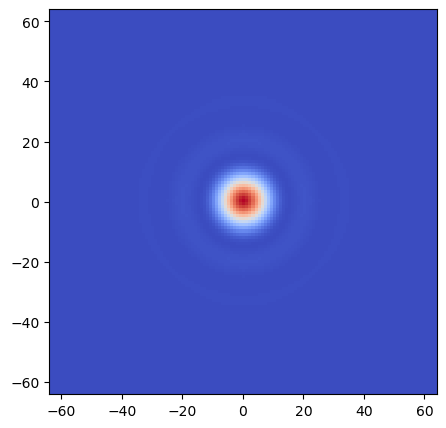

In [190]:
# random testing
roi_size = 200
NA = 0.65
lam = 589
camera_um_per_px = 1.85 # 6.45
imaging_magnification = 49.7
viewing_roi_size = 128
pupil_radius_in_pixels = round(NA * roi_size * camera_um_per_px / (lam * 1e-3 * imaging_magnification))
psf_plane_um_per_px = camera_um_per_px

# underlying pixel grid
x_pix = np.linspace(-roi_size/2, roi_size/2, roi_size)
y_pix = np.linspace(-roi_size/2, roi_size/2, roi_size)
[X_pix,Y_pix] = np.meshgrid(x_pix,y_pix)

Z00 = 0
Zm11,Z11 = 0,0
Zm22,Z02,Z22 = 0.0,0.02, 0.0
Zm33,Zm13,Z13,Z33 = 0,0.0,0.0,0
Zm44,Zm24,Z04,Z24,Z44 = 0,0,0.00,0,0

p = pupil([X_pix, Y_pix], pupil_radius_in_pixels)
a = aberration([X_pix, Y_pix], pupil_radius_in_pixels, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)
c = complex_pupil([X_pix,Y_pix], pupil_radius_in_pixels, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)

psf = psf_profile([X_pix,Y_pix], pupil_radius_in_pixels, 1, 0, 0, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)
# psf_065 = psf_profile([X_pix,Y_pix], pupil_radius_in_pixels, 1, 0, 0, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)

plt.figure(figsize = (5,5))
plt.pcolor(X_pix, Y_pix, psf, cmap = 'coolwarm')
plt.xlim([-viewing_roi_size//2, viewing_roi_size//2])
plt.ylim([-viewing_roi_size//2, viewing_roi_size//2])
# plt.axis('square')
plt.show()

In [191]:
# single-image analysis
image_filename = 'FLIR_2.tiff'
image_file = '/Users/huanbui/Desktop/microscope_testing/20250211/FLIR/' + image_filename
dark_file = '/Users/huanbui/Desktop/microscope_testing/20250211/FLIR/FLIR_dark.tiff'
upscale_factor = 1
roi_size = 200 * upscale_factor

In [192]:
# do fit
lam = 589
camera_magnification = 1.85 * upscale_factor # 6.45 / upscale_factor
imaging_magnification = 49.5 # 47.7
viewing_roi_size = 128 * upscale_factor # 40 * upscale_factor
# crop to get a smaller image to work faster
dark = Image.open(dark_file)
im = Image.open(image_file)

# upscale 
im = np.array(im.resize(size=(im.size[0]*upscale_factor, im.size[1]*upscale_factor), resample= Image.NEAREST), dtype = 'int64')
dark = np.array(dark.resize(size=(dark.size[0]*upscale_factor, dark.size[0]*upscale_factor), resample= Image.NEAREST), dtype = 'int64')
im = im - dark

# poor man's center finding 
x_center_guess, y_center_guess = np.unravel_index(im.argmax(), im.shape)

# re-crop so that feature is as centered as possible
centered_cropped = im[round(x_center_guess - roi_size/2) : round(x_center_guess + roi_size/2), 
                      round(y_center_guess - roi_size/2) : round(y_center_guess + roi_size/2)]
# make space of underlying pixel grid
x_pix = np.linspace(-roi_size/2, roi_size/2, roi_size)
y_pix = np.linspace(-roi_size/2, roi_size/2, roi_size)
[X_pix,Y_pix] = np.meshgrid(x_pix,y_pix)

# do fit
res, data_fitted = fit_zernike([X_pix, Y_pix], centered_cropped)
# normalize to find Strehl ratio:
data_fitted /= np.max(data_fitted)
centered_cropped = np.nansum(data_fitted) * centered_cropped / np.nansum(centered_cropped)
# get NA and Strehl ratio
NA_from_fit = (res.values['pupil_radius_in_pixels'] * lam * 1e-3 * imaging_magnification) / (roi_size * camera_magnification)
Strehl_from_fit = np.max(centered_cropped) / np.max(data_fitted)

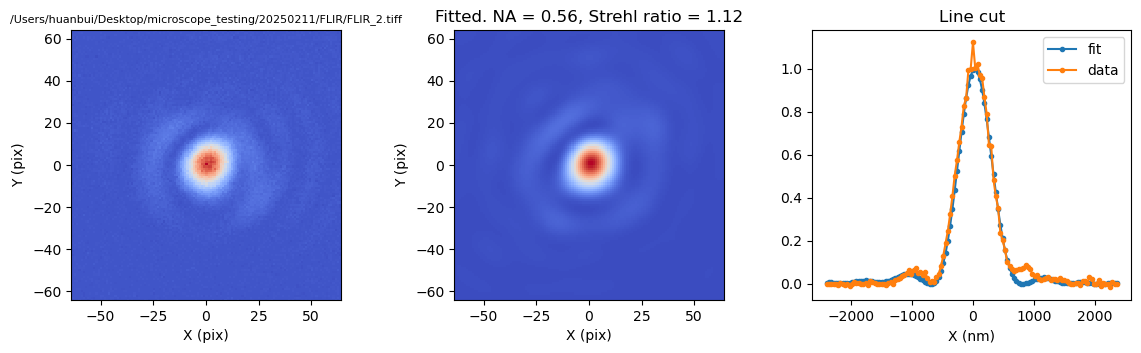

{'pupil_radius_in_pixels': np.float64(7.141872172008351),
 'amplitude': np.float64(59176.57199815708),
 'offset': np.float64(-87.64988260598648),
 'theta': 0,
 'Z00': 0.0,
 'Zm11': np.float64(0.03628370254962601),
 'Z11': np.float64(0.016942980385730333),
 'Zm22': np.float64(0.04968438564291486),
 'Z02': np.float64(0.08886433067564309),
 'Z22': np.float64(-0.001132126625123464),
 'Zm33': np.float64(0.007976508191002818),
 'Zm13': np.float64(0.05431543920360227),
 'Z13': np.float64(-0.021808229345426394),
 'Z33': np.float64(0.00894773648296776),
 'Zm44': 0.0,
 'Zm24': 0.0,
 'Z04': np.float64(0.07729766747686934),
 'Z24': 0.0,
 'Z44': 0.0}

In [193]:
# plot results
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (14, 3.5))
ax[0].pcolor(X_pix, Y_pix, centered_cropped, cmap = 'coolwarm')
ax[0].axis('square')
ax[0].set_xlim([-viewing_roi_size/2, viewing_roi_size/2])
ax[0].set_ylim([-viewing_roi_size/2, viewing_roi_size/2])
ax[0].set_xlabel('X (pix)')
ax[0].set_ylabel('Y (pix)')
ax[0].set_title(f'{image_file}', fontsize = 8)

ax[1].pcolor(X_pix, Y_pix, data_fitted, cmap = 'coolwarm')
ax[1].axis('square')
ax[1].set_xlim([-viewing_roi_size/2, viewing_roi_size/2])
ax[1].set_ylim([-viewing_roi_size/2, viewing_roi_size/2])
ax[1].set_xlabel('X (pix)')
ax[1].set_ylabel('Y (pix)')
ax[1].set_title(f'Fitted. NA = {NA_from_fit:.2f}, Strehl ratio = {Strehl_from_fit:.2f}')

r_plot = np.arange(-viewing_roi_size//2, viewing_roi_size//2) * camera_magnification * 1e3 / imaging_magnification # um
ax[2].plot(r_plot, data_fitted[data_fitted.shape[0]//2, data_fitted.shape[0]//2-viewing_roi_size//2:data_fitted.shape[0]//2+viewing_roi_size//2], '.-', label = 'fit')
ax[2].plot(r_plot, centered_cropped[data_fitted.shape[0]//2, data_fitted.shape[0]//2-viewing_roi_size//2:data_fitted.shape[0]//2+viewing_roi_size//2], '.-', label = 'data')
ax[2].set_title('Line cut')
ax[2].set_xlabel('X (nm)')
ax[2].legend()
plt.show()

# show best values
res.best_values

# <font size = 5>Deconvolution of quantum gas microscope images</font>

In [72]:
# helper functions
def psf_2d(x, y, NA = 0.7, lam = 589):
    R = 0.61 * lam / NA # radius of first zero, lam in nm
    Rz = 1.2196698912665045
    u = np.pi * np.sqrt(x**2 + y**2) / (R/Rz) # r in nm
    return (2 * jn(1, u) / u)**2

def dark_BG(mu, sigma, size):
    return np.reshape(halfnorm.rvs(loc = mu, scale = sigma, size=size**2), (size, size) )

def FT_no_DC(signal, bin_size = 1):
    ft = fft(signal)
    abs_ft = np.abs(ft)[1:round(len(signal)//2)] # skip the DC part
    freqs  = np.fft.fftfreq(len(signal), d=bin_size)[1:round(len(signal)//2)]
    return abs_ft/np.max(abs_ft), freqs

def lattice_spacing_and_phase(freqs, data, low_cutoff, high_cutoff):
    masked_data = np.ma.masked_where((freqs < low_cutoff) | (freqs > high_cutoff), data, copy = True)
    ind = np.argmax(masked_data)
    return round(1/freqs[ind])

# Wiener deconvolution
def wiener(camera_image, psf, K, camera_pix_per_um, psf_pix_per_um, camera_ROI_size):
    # upscale image such that the psf and the camera image has the same "magnification"
    upscale_factor = psf_pix_per_um/camera_pix_per_um
    upscaled_camera_image = np.array(Image.fromarray(camera_image).resize(size=(round(camera_ROI_size*upscale_factor), 
                                                                                round(camera_ROI_size*upscale_factor)), 
                                                                        resample= Image.NEAREST))
    # TODO: extend this to cover more cases
    if psf.shape[0] < upscaled_camera_image.shape[0]:
        diff0 = upscaled_camera_image.shape[0] - psf.shape[0]
        diff1 = upscaled_camera_image.shape[1] - psf.shape[1]
        top_pad = diff0//2
        bottom_pad = diff0 - top_pad
        right_pad = diff1//2
        left_pad = diff1 - right_pad
        psf = np.pad(psf, ((top_pad, bottom_pad), (right_pad, left_pad)), 'constant')
    
    psf /= np.sum(psf) # normalize PSF
    F_psf = fft2(psf)
    FI = fft2(upscaled_camera_image)

    # apply Fermi-Dirac low-pass filter
    # fr = np.arange(0, FI.shape[0]) - FI.shape[0]//2
    # fc = np.arange(0, FI.shape[1]) - FI.shape[1]//2
    # FR, FC = np.meshgrid(fr, fc)
    # q = np.sqrt(FR**2 + FC**2)
    # qw = 10
    # q0 = 2 # should match the spatial frequency of the lattice, to enhance this frequency!
    # FD_filter = 2 / (np.exp( (q-q0)/qw ) + 1)
    FD_filter = 1
    FI = FI * FD_filter
    w = ifft2(FI * np.conj(F_psf) / (np.abs(F_psf)**2 + K))    
    w = np.abs(ifftshift(w))
    return w

# deconvolve and find lattice spacing
def deconvolve_and_find_lattice_spacing(camera_image, psf, wiener_param, lattice_constant, camera_pix_per_um, psf_pix_per_um, camera_ROI_size):
    w = wiener(camera_image, psf, wiener_param, camera_pix_per_um, psf_pix_per_um, camera_ROI_size)
    # locate peaks and plot histogram of distances between the x-coordinates and y-coordinates of the peaks
    peaks = skimage.feature.peak_local_max(w, min_distance = round(psf_pix_per_um * lattice_constant * 1e-3)) 
    x_peaks, y_peaks = peaks[:,0], peaks[:,1]
    diff_px, diff_py = [], [] # these lists have the same length!
    for i in range(len(x_peaks)):
        for j in np.arange(i,len(x_peaks)-1):
            diff_px.append(abs(x_peaks[j] - x_peaks[i]))
            diff_py.append(abs(y_peaks[j] - y_peaks[i]))
    # generate histograms:
    diff_px_counts, diff_px_binned = np.histogram(diff_px, bins = round(np.sqrt(len(diff_px))/2))
    diff_py_counts, diff_py_binned = np.histogram(diff_py, bins = round(np.sqrt(len(diff_py))/2))
    diff_px_binned, diff_py_binned = diff_px_binned[:-1], diff_py_binned[:-1]
    # compute FFT of the differences:
    fdiff_px_counts, freq_diff_px_counts = FT_no_DC(signal = diff_px_counts, bin_size = w.shape[0]/round(np.sqrt(len(diff_px))/2))
    fdiff_py_counts, freq_diff_py_counts = FT_no_DC(signal = diff_py_counts, bin_size = w.shape[1]/round(np.sqrt(len(diff_py))/2))

    # Find the most prominent peak. Typically we don't expect features with 1/4px >= spatial frequencies >= 1/(psf_px_per_lattice constant + 2)
    psf_per_lattice_constant = psf_pix_per_um * (lattice_constant * 1e-3)
    low_cutoff, high_cutoff = 1/(psf_per_lattice_constant + 2), 1/4.5

    # compute lattice spacing and phase
    lattice_spacing_x = lattice_spacing_and_phase(freq_diff_px_counts, fdiff_px_counts, low_cutoff, high_cutoff)
    lattice_spacing_y = lattice_spacing_and_phase(freq_diff_py_counts, fdiff_py_counts, low_cutoff, high_cutoff)

    res = {}
    res['deconvolved_image'] = w
    res['diff_px_binned'] = diff_px_binned
    res['diff_py_binned'] = diff_py_binned
    res['diff_px_counts'] = diff_px_counts
    res['diff_py_counts'] = diff_py_counts
    res['lattice_spacing_x'] = lattice_spacing_x
    res['lattice_spacing_y'] = lattice_spacing_y
    res['freq_diff_px_counts'] = freq_diff_px_counts
    res['freq_diff_py_counts'] = freq_diff_py_counts
    res['fdiff_px_counts'] = fdiff_px_counts
    res['fdiff_py_counts'] = fdiff_py_counts
    res['freq_diff_px_counts'] = freq_diff_px_counts
    res['freq_diff_py_counts'] = freq_diff_py_counts

    return res

# find the lattice phase and crop so that image dimensions are n * lattice spacing in pixels
def find_lattice_phase_and_crop(image, lattice_spacing_x, lattice_spacing_y, ):
    lattice_phase = (0,0)
    best_cropped = None
    lattice_binned_image = None
    old_contrast = -1
    for i in range(lattice_spacing_x):
        for j in range(lattice_spacing_y):
            cropped = image[i: image.shape[0]- image.shape[0]%lattice_spacing_x - (lattice_spacing_x - i),
                            j: image.shape[0]- image.shape[1]%lattice_spacing_y - (lattice_spacing_y - j)]
            # now bin into underlying lattice:
            binned = np.array(Image.fromarray(cropped).resize(size=(cropped.shape[0]//lattice_spacing_x, cropped.shape[1]//lattice_spacing_y), resample= Image.NEAREST))
            # compute "contrast"
            contrast = np.std(binned.ravel())
            if contrast > old_contrast:
                old_contrast = contrast
                lattice_phase = (i, j)
                best_cropped = cropped
                lattice_binned_image = binned
    return lattice_phase, best_cropped, lattice_binned_image

# fit to one-half gaussian
def fit_to_one_half_gaussian(x,data):
    def one_half_gaussian(x, mu, amp1, amp2, sigma1, sigma2, offset1, offset2):
        gauss1 = amp1 * np.exp(-0.5 * (x/sigma1)**2) + offset1
        gauss2 = amp2 * np.exp(-0.5 * ((x - mu)/sigma2)**2) + offset2
        return gauss1 + gauss2

    params = Parameters()
    params.add('mu', value = 0.9 * np.max(x), min = -np.max(x), max = np.max(x))
    params.add('amp1', value = np.max(data), min = 0)
    params.add('amp2', value = np.max(data)/10, min = 0)
    params.add('sigma1', value = np.max(x), min = 0)
    params.add('sigma2', value = np.max(x), min = 0)
    params.add('offset1', value = 0)
    params.add('offset2', value = 0)
    model = Model(one_half_gaussian)
    result = model.fit(data, params, x = x)

    # threshold is where the gaussians intersect:   
    s1,s2 = result.best_values['sigma1'],result.best_values['sigma2']
    amp1, amp2 = result.best_values['amp1'], result.best_values['amp2']
    mu = result.best_values['mu']
    threshold1 = (mu*s1**2 - np.sqrt((mu*s1*s2)**2 - 2*s1**4*s2**2*np.log(amp1/amp2) + 2*s1**2*s2**4*np.log(amp1/amp2)))/(s1**2 - s2**2)
    threshold2 = (mu*s1**2 + np.sqrt((mu*s1*s2)**2 - 2*s1**4*s2**2*np.log(amp1/amp2) + 2*s1**2*s2**4*np.log(amp1/amp2)))/(s1**2 - s2**2)

    if threshold1*threshold2 <= 0:
        threshold = max(threshold1, threshold2)
    elif threshold1 + threshold2 <= 0:
        threshold = 0
    else:
        threshold = min(threshold1, threshold2)

    # calculate overlap
    return result, threshold

# post-process lattice image
def post_process_lattice_image(w, lattice_spacing_x, lattice_spacing_y):
    lattice_info = {}
    # find phase and crop to make lattice-binned image
    lattice_phase, best_cropped, lattice_binned_image = find_lattice_phase_and_crop(w, lattice_spacing_x, lattice_spacing_y)
    # generate histogram of lattice-binned image
    occurrences, intensities = np.histogram(lattice_binned_image.ravel(), bins = round(np.sqrt(len(lattice_binned_image.ravel()))))
    intensities = intensities[:-1]
    # fit to one-half gaussian
    fit_result, threshold = fit_to_one_half_gaussian(intensities, occurrences)

    lattice_info['lattice_phase'] = lattice_phase
    lattice_info['best_cropped'] = best_cropped
    lattice_info['lattice_binned_image'] = lattice_binned_image
    lattice_info['fit_result'] = fit_result
    lattice_info['threshold'] = threshold  
    lattice_info['occurrences'] = occurrences
    lattice_info['intensities'] = intensities
    
    return lattice_info

In [8]:
# Wiener deconvolution
def wiener(camera_image, psf, K, camera_pix_per_um, psf_pix_per_um, camera_ROI_size):
    # upscale image such that the psf and the camera image has the same "magnification"
    upscale_factor = psf_pix_per_um/camera_pix_per_um
    upscaled_camera_image = np.array(Image.fromarray(camera_image).resize(size=(round(camera_ROI_size*upscale_factor), 
                                                                                round(camera_ROI_size*upscale_factor)), 
                                                                        resample= Image.NEAREST))
    # TODO: extend this to cover more cases
    if psf.shape[0] < upscaled_camera_image.shape[0]:
        diff0 = upscaled_camera_image.shape[0] - psf.shape[0]
        diff1 = upscaled_camera_image.shape[1] - psf.shape[1]
        top_pad = diff0//2
        bottom_pad = diff0 - top_pad
        right_pad = diff1//2
        left_pad = diff1 - right_pad
        psf = np.pad(psf, ((top_pad, bottom_pad), (right_pad, left_pad)), 'constant')
    
    psf /= np.sum(psf) # normalize PSF
    F_psf = fft2(psf)
    FI = fft2(upscaled_camera_image)

    # apply Fermi-Dirac low-pass filter
    # fr = np.arange(0, FI.shape[0]) - FI.shape[0]//2
    # fc = np.arange(0, FI.shape[1]) - FI.shape[1]//2
    # FR, FC = np.meshgrid(fr, fc)
    # q = np.sqrt(FR**2 + FC**2)
    # qw = 10
    # q0 = 2 # should match the spatial frequency of the lattice, to enhance this frequency!
    # FD_filter = 2 / (np.exp( (q-q0)/qw ) + 1)
    FD_filter = 1
    FI = FI * FD_filter
    w = ifft2(FI * np.conj(F_psf) / (np.abs(F_psf)**2 + K))    
    w = np.abs(ifftshift(w))
    return w

In [47]:
# commonly used parameters
NA = 0.55
filling_fraction = 0.2
lattice_size = 100 # in units of lattice constants
sigmaBG = 100 # but can be anything
wiener_param_Na = 0.05
wiener_param_K  = 0.008

In [48]:
# optical lattice and imaging parameters
lattice_constant = 532
lam_Na = 589
lam_K  = 767
imaging_magnification = 63 # 51.7
pixel_size = 13.0 # um per pixel
pixels_per_lattice_constant = imaging_magnification * lattice_constant * 1e-3 / pixel_size # camera pixels
effective_magnification = pixel_size/imaging_magnification
camera_pix_per_um = 1/effective_magnification # camera pixels per um in object plane
typ_fluo_level_per_site = 10000
lattice_padding = 2 # in units of lattice constants, must be even
camera_ROI_size = int((lattice_size + lattice_padding) * lattice_constant / (effective_magnification*1000)) # camera pixels
psf_kernel_size = 5 # in units of lattice constants
pixels_per_site = 2*4 # in upscale pixels, for generating true image, must be even
psf_pix_per_um = 6 / (lattice_constant * 1e-3) #
muBG = 100 # counts per pixel of dark counts

In [49]:
# calculate boundaries of lattice in nm:
lattice_lim = (lattice_size + lattice_padding) * lattice_constant/2
# python pixel dimension for true image:
true_image_dim_in_pix = (lattice_size + lattice_padding) * pixels_per_site

# generate various coordinate systems:
# real-space lattice with padding by 1 lattice constant
x_nm_lattice = np.linspace(-lattice_lim, lattice_lim, true_image_dim_in_pix)
y_nm_lattice = np.linspace(-lattice_lim, lattice_lim, true_image_dim_in_pix)

# psf space
x_nm_psf = np.linspace(-psf_kernel_size * lattice_constant/2, psf_kernel_size * lattice_constant/2, psf_kernel_size*pixels_per_site)
y_nm_psf = np.linspace(-psf_kernel_size * lattice_constant/2, psf_kernel_size * lattice_constant/2, psf_kernel_size*pixels_per_site)
X_nm_psf, Y_nm_psf = np.meshgrid(x_nm_psf, y_nm_psf)

# camera space
[X_camera, Y_camera] = np.meshgrid(np.arange(-camera_ROI_size/2, camera_ROI_size/2),np.arange(-camera_ROI_size/2, camera_ROI_size/2))

In [50]:
# initialize lattice
lattice_Na = np.random.choice([0, 1], size=(lattice_size, lattice_size), p=[1-filling_fraction, filling_fraction])
lattice_K  = np.random.choice([0, 1], size=(lattice_size, lattice_size), p=[1-filling_fraction, filling_fraction])

# randomize fluoresence intensity
fluo_intensity_Na = np.random.poisson(typ_fluo_level_per_site, size=(lattice_size, lattice_size)) * lattice_Na
fluo_intensity_K  = np.random.poisson(typ_fluo_level_per_site, size=(lattice_size, lattice_size)) * lattice_K

# convert into real-space lattice, with padding by 1 lattice constant
real_space_lattice_Na = np.zeros((len(x_nm_lattice), len(y_nm_lattice)))
real_space_lattice_Na[round(pixels_per_site*(1/2+lattice_padding//2)):-pixels_per_site*lattice_padding//2:pixels_per_site, 
                      round(pixels_per_site*(1/2+lattice_padding//2)):-pixels_per_site*lattice_padding//2:pixels_per_site] = np.multiply(lattice_Na,fluo_intensity_Na)

real_space_lattice_K  = np.zeros((len(x_nm_lattice), len(y_nm_lattice)))
real_space_lattice_K[round(pixels_per_site*(1/2+lattice_padding//2)):-pixels_per_site*lattice_padding//2:pixels_per_site, 
                     round(pixels_per_site*(1/2+lattice_padding//2)):-pixels_per_site*lattice_padding//2:pixels_per_site] = np.multiply(lattice_K,fluo_intensity_K)

In [51]:
# generate PSF for each species
psf_Na = psf_2d(X_nm_psf, Y_nm_psf, NA=NA, lam=lam_Na)
psf_K  = psf_2d(X_nm_psf, Y_nm_psf, NA=NA, lam=lam_K)

# convolve this with real image (no noise) with python mahotas instead of scipy
convolved_image_Na = mahotas.convolve(real_space_lattice_Na, psf_Na)
convolved_image_K  = mahotas.convolve(real_space_lattice_K , psf_K)

# generate noise and dark image for subtraction later
dark_image_Na = dark_BG(mu=muBG, sigma=sigmaBG, size=camera_ROI_size)
dark_image_K  = dark_BG(mu=muBG, sigma=sigmaBG, size=camera_ROI_size)
dark_image_Na_for_subtraction = dark_BG(mu=muBG, sigma=sigmaBG, size=camera_ROI_size)
dark_image_K_for_subtraction  = dark_BG(mu=muBG, sigma=sigmaBG, size=camera_ROI_size)

camera_image_Na = np.array(Image.fromarray(convolved_image_Na).resize(size=(camera_ROI_size, camera_ROI_size), resample= Image.NEAREST))
camera_image_with_noise_Na = camera_image_Na + dark_image_Na - dark_image_Na_for_subtraction

camera_image_K = np.array(Image.fromarray(convolved_image_K).resize(size=(camera_ROI_size, camera_ROI_size), resample= Image.NEAREST))
camera_image_with_noise_K = camera_image_K + dark_image_K - dark_image_K_for_subtraction

# calculate SNR by taking the mean fluo intensity over the occupied sites / background signal
snr_Na = np.sum(fluo_intensity_Na) / (np.sum(lattice_Na) * sigmaBG)
snr_K  = np.sum(fluo_intensity_K)  / (np.sum(lattice_K)  * sigmaBG)

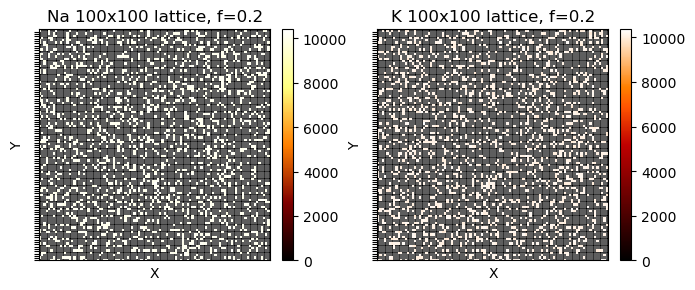

In [52]:
# show lattices
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))

# Na lattice
ax0 = ax[0].pcolor(fluo_intensity_Na, cmap='afmhot') # can also do lattice_Na
ax[0].axis('square')
ax[0].set_title(f'Na {lattice_size}x{lattice_size} lattice, f={filling_fraction}')
ax[0].set_xticks(np.arange(0, lattice_size), ['']*lattice_size) 
ax[0].set_yticks(np.arange(0, lattice_size), ['']*lattice_size) 
ax[0].grid(color = 'white', linewidth = 0.3)
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
ax[0].tick_params(axis='x', bottom=False, labelbottom=False) 
ax[0].tick_params(axis='y', bottom=False, labelbottom=False) 
fig.colorbar(ax0, fraction=0.046, pad=0.04, ax=ax[0])

# K lattice
ax1 = ax[1].pcolor(fluo_intensity_K, cmap='gist_heat') # can also do lattice_K
ax[1].axis('square')
ax[1].set_title(f'K {lattice_size}x{lattice_size} lattice, f={filling_fraction}')
ax[1].set_xticks(np.arange(0, lattice_size), ['']*lattice_size) 
ax[1].set_yticks(np.arange(0, lattice_size), ['']*lattice_size) 
ax[1].grid(color = 'white', linewidth = 0.3)
ax[1].set_xlabel('X')
ax[1].set_ylabel('Y')
ax[1].tick_params(axis='x', bottom=False, labelbottom=False) 
ax[1].tick_params(axis='y', bottom=False, labelbottom=False) 
fig.colorbar(ax1, fraction=0.046, pad=0.04, ax=ax[1])
plt.show()

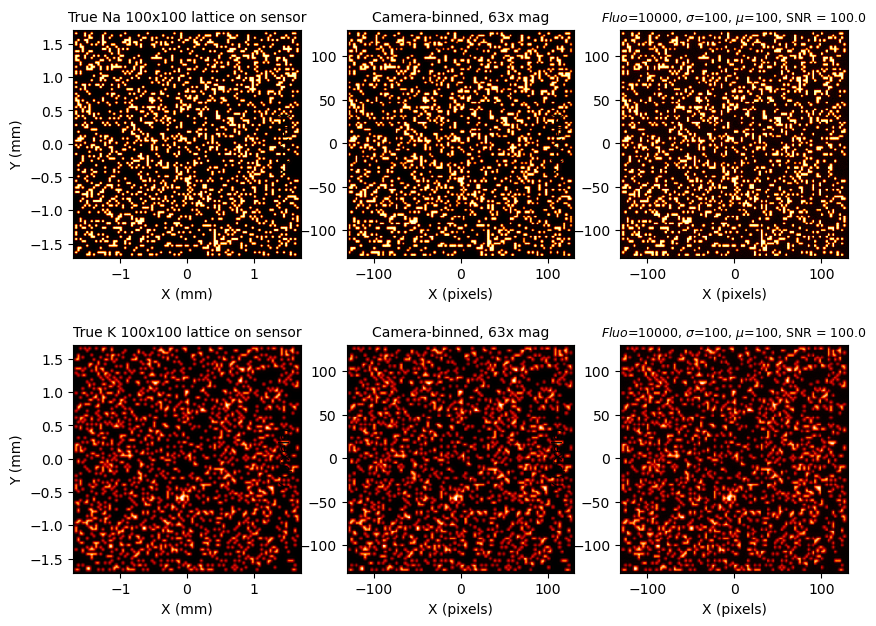

In [53]:
# show true image to camera-binned to noisy
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(10, 7.5))
ax00 = ax[0][0].pcolor(x_nm_lattice*imaging_magnification/1e6, y_nm_lattice*imaging_magnification/1e6, convolved_image_Na, cmap='afmhot')
ax[0][0].set_title(f'True Na {lattice_size}x{lattice_size} lattice on sensor', fontsize = 10)
ax[0][0].set_xlabel('X (mm)')
ax[0][0].set_ylabel('Y (mm)')

ax10 = ax[1][0].pcolor(x_nm_lattice*imaging_magnification/1e6, y_nm_lattice*imaging_magnification/1e6, convolved_image_K, cmap='gist_heat')
ax[1][0].set_title(f'True K {lattice_size}x{lattice_size} lattice on sensor', fontsize = 10)
ax[1][0].set_xlabel('X (mm)')
ax[1][0].set_ylabel('Y (mm)')

ax01 = ax[0][1].pcolor(X_camera, Y_camera, camera_image_Na, cmap='afmhot')
ax[0][1].set_title(f'Camera-binned, {imaging_magnification}x mag', fontsize = 10)
ax[0][1].set_xlabel('X (pixels)')
ax[0][1].set_ylabel('Y (pixels)')

ax11 = ax[1][1].pcolor(X_camera, Y_camera, camera_image_K, cmap='gist_heat') 
ax[1][1].set_title(f'Camera-binned, {imaging_magnification}x mag', fontsize = 10)
ax[1][1].set_xlabel('X (pixels)')
ax[1][1].set_ylabel('Y (pixels)')

ax02 = ax[0][2].pcolor(X_camera, Y_camera, camera_image_with_noise_Na, cmap='afmhot') 
ax[0][2].set_title(f'$Fluo$={typ_fluo_level_per_site}, $\sigma$={sigmaBG}, $\mu$={muBG}, SNR = {snr_Na:.1f}', fontsize = 9)
ax[0][2].set_xlabel('X (pixels)')
ax[0][2].set_ylabel('Y (pixels)')

ax12 = ax[1][2].pcolor(X_camera, Y_camera, camera_image_with_noise_K, cmap='gist_heat') 
ax[1][2].set_title(f'$Fluo$={typ_fluo_level_per_site}, $\sigma$={sigmaBG}, $\mu$={muBG}, SNR = {snr_Na:.1f}', fontsize = 9)
ax[1][2].set_xlabel('X (pixels)')
ax[1][2].set_ylabel('Y (pixels)')

for i in range(2):
    for j in range(3):
        ax[i][j].axis('square')

plt.show()

In [54]:
# deconvolve and find lattice spacing
Na_lattice_pre_info = deconvolve_and_find_lattice_spacing(camera_image_with_noise_Na, psf_Na, 
                                                          wiener_param_Na, lattice_constant, camera_pix_per_um, psf_pix_per_um, camera_ROI_size)
K_lattice_pre_info = deconvolve_and_find_lattice_spacing(camera_image_with_noise_K, psf_K,
                                                         wiener_param_K, lattice_constant, camera_pix_per_um, psf_pix_per_um, camera_ROI_size)

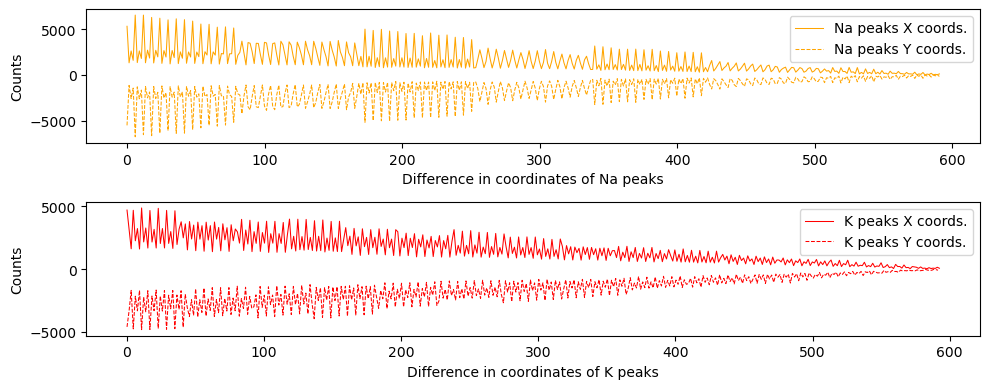

In [64]:
# plot histograms of differences in the X- and Y- coordinates of peaks
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (10,4))
ax[0].plot(Na_lattice_pre_info['diff_px_binned'], Na_lattice_pre_info['diff_px_counts'], linewidth = 0.75, color = 'orange', label = 'Na peaks X coords.')
ax[0].plot(Na_lattice_pre_info['diff_py_binned'], -Na_lattice_pre_info['diff_py_counts'], '--', linewidth = 0.75, color = 'orange', label = 'Na peaks Y coords.')
ax[0].legend()
ax[1].plot(K_lattice_pre_info['diff_px_binned'], K_lattice_pre_info['diff_px_counts'], linewidth=0.75, color = 'red', label = 'K peaks X coords.')
ax[1].plot(K_lattice_pre_info['diff_py_binned'], -K_lattice_pre_info['diff_py_counts'], '--', linewidth = 0.75, color = 'red', label = 'K peaks Y coords.')
ax[1].legend()
ax[0].set_xlabel('Difference in coordinates of Na peaks')
ax[0].set_ylabel('Counts')
ax[1].set_xlabel('Difference in coordinates of K peaks')
ax[1].set_ylabel('Counts')
plt.tight_layout()
plt.show()

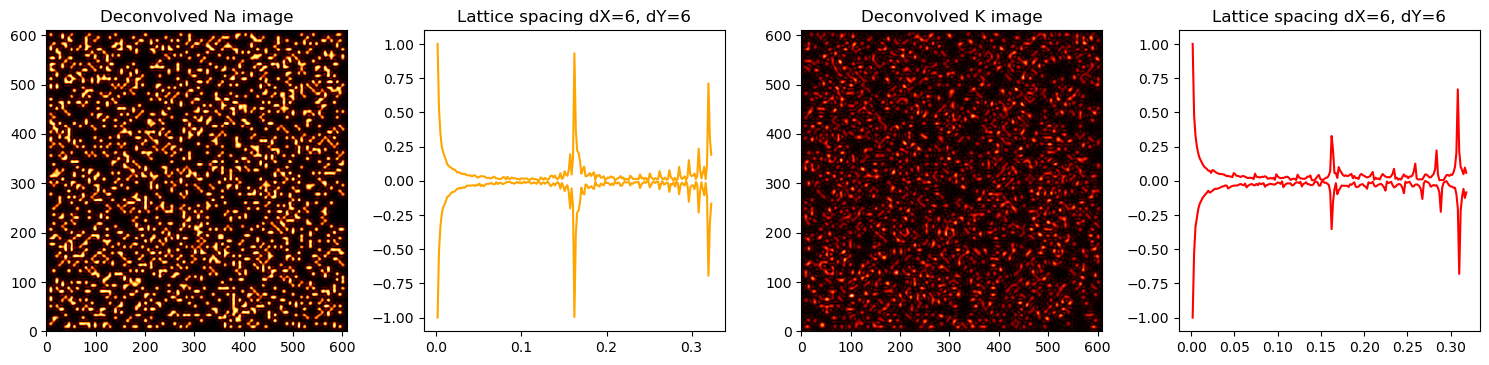

In [69]:
# show upscaled deconvolved images and lattice spacing
fig, ax = plt.subplots(nrows = 1, ncols = 4, figsize = (15,6))
ax[0].pcolor(Na_lattice_pre_info['deconvolved_image'], cmap = 'afmhot')
ax[0].axis('square')
ax[0].set_title('Deconvolved Na image')
ax[1].plot(Na_lattice_pre_info['freq_diff_px_counts'], Na_lattice_pre_info['fdiff_px_counts'], color = 'orange')
ax[1].plot(Na_lattice_pre_info['freq_diff_px_counts'], -Na_lattice_pre_info['fdiff_py_counts'], color = 'orange')
ax[1].set_title(f'Lattice spacing dX={Na_lattice_pre_info["lattice_spacing_x"]}, dY={Na_lattice_pre_info["lattice_spacing_y"]}')
ax[1].set_box_aspect(1)
ax[2].pcolor(K_lattice_pre_info['deconvolved_image'], cmap = 'gist_heat')
ax[2].axis('square')
ax[2].set_title('Deconvolved K image')
ax[3].plot(K_lattice_pre_info['freq_diff_px_counts'], K_lattice_pre_info['fdiff_px_counts'], color = 'red')
ax[3].plot(K_lattice_pre_info['freq_diff_px_counts'], -K_lattice_pre_info['fdiff_py_counts'], color = 'red')
ax[3].set_title(f'Lattice spacing dX={Na_lattice_pre_info["lattice_spacing_x"]}, dY={Na_lattice_pre_info["lattice_spacing_y"]}')
ax[3].set_box_aspect(1)
plt.tight_layout()
plt.show()

In [73]:
# post-process lattice image from known lattice spacing
Na_lattice_info = post_process_lattice_image(Na_lattice_pre_info['deconvolved_image'], 
                                             Na_lattice_pre_info['lattice_spacing_x'], Na_lattice_pre_info['lattice_spacing_y'])
K_lattice_info  = post_process_lattice_image(K_lattice_pre_info['deconvolved_image'], 
                                             K_lattice_pre_info['lattice_spacing_x'], K_lattice_pre_info['lattice_spacing_y'])

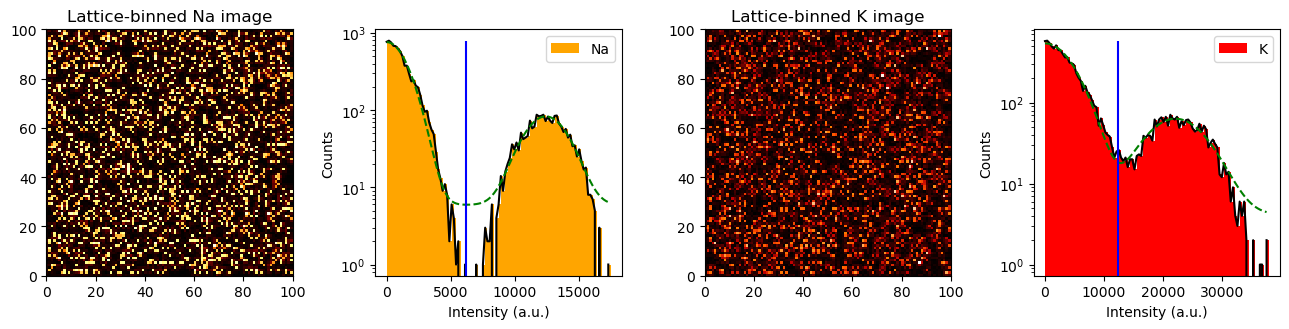

In [76]:
# plot occupation thresholding histograms
fig, ax = plt.subplots(nrows=1, ncols=4, figsize = (13,4))
ax[0].pcolor(Na_lattice_info['lattice_binned_image'], cmap = 'afmhot')
ax[0].axis('square')
ax[0].set_title('Lattice-binned Na image')
ax[1].hist(Na_lattice_info['lattice_binned_image'].ravel(), 
           bins = round(np.sqrt(len(Na_lattice_info['lattice_binned_image'].ravel()))), color = 'orange', label = 'Na', log=True)
ax[1].plot(Na_lattice_info['intensities'], Na_lattice_info['occurrences'], color = 'black')
ax[1].plot(Na_lattice_info['intensities'], Na_lattice_info['fit_result'].best_fit, '--', color = 'green')
ax[1].vlines(Na_lattice_info['threshold'], ymin=np.min(Na_lattice_info['occurrences']),ymax=np.max(Na_lattice_info['occurrences']), color = 'blue')
ax[1].set_xlabel('Intensity (a.u.)')
ax[1].set_ylabel('Counts')
ax[1].set_box_aspect(1)
ax[1].legend()
ax[2].pcolor(K_lattice_info['lattice_binned_image'], cmap = 'gist_heat')
ax[2].axis('square')
ax[2].set_title('Lattice-binned K image')
ax[3].hist(K_lattice_info['lattice_binned_image'].ravel(), 
           bins = round(np.sqrt(len(K_lattice_info['lattice_binned_image'].ravel()))), color = 'red', label = 'K', log=True)
ax[3].plot(K_lattice_info['intensities'], K_lattice_info['occurrences'], color = 'black')
ax[3].plot(K_lattice_info['intensities'], K_lattice_info['fit_result'].best_fit, '--', color = 'green')
ax[3].vlines(K_lattice_info['threshold'], ymin=np.min(K_lattice_info['occurrences']),ymax=np.max(K_lattice_info['occurrences']), color = 'blue')
ax[3].set_xlabel('Intensity (a.u.)')
ax[3].set_ylabel('Counts')
ax[3].set_box_aspect(1)
ax[3].legend()
plt.tight_layout()
plt.show()

# <font size = 5>To do</font>

- Implement auto threshold finder for find_lattice_phase_and_crop()
- Treat cases with image tilt and != 90 degree lattice beams
- Optimize Wiener parameter for Na and K
- Verify wavefront expansion analysis is good